In [9]:
# Environment & imports
import sys
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Python excecutable:", sys.executable)

sys.path.append(str(Path.cwd().parent))
from src.simulation import simulate_sir, choose_immunized_by_degree

Python excecutable: /home/jonjon-levi/CoursesUCLA/Networks/disease-propogation-network/.venv/bin/python


In [12]:
n = 400
p = 0.01
G = nx.erdos_renyi_graph(n, p)  # undirected random graph

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Avg degree:", sum(dict(G.degree()).values()) / n)


Nodes: 400
Edges: 765
Avg degree: 3.825


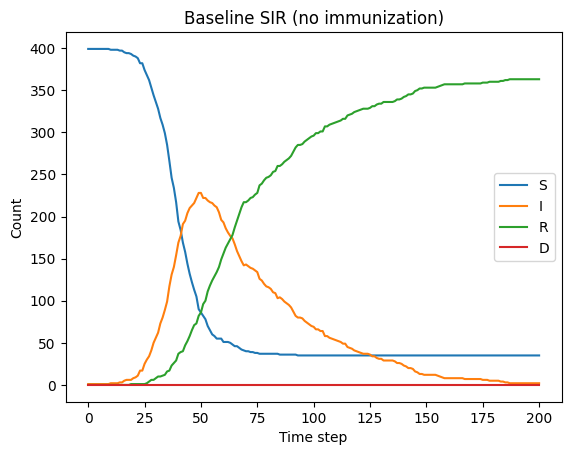

In [19]:
beta = 0.08
gamma = 0.03
steps = 200

initial_infected = [0]          # seed infection at node 0
rng = np.random.default_rng(42) # reproducible run

out0 = simulate_sir(
    G,
    beta=beta,
    gamma=gamma,
    steps=steps,
    initial_infected=initial_infected,
    immunized=set(),
    rng=rng
)

plt.plot(out0["S"], label="S")
plt.plot(out0["I"], label="I")
plt.plot(out0["R"], label="R")
plt.plot(out0["D"], label="D")
plt.title("Baseline SIR (no immunization)")
plt.xlabel("Time step")
plt.ylabel("Count")
plt.legend()
plt.show()

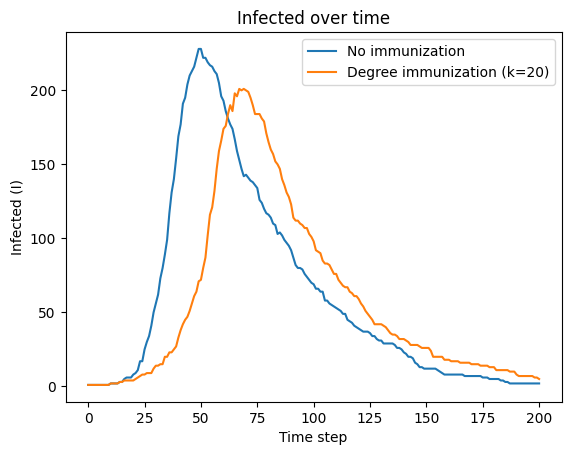

In [21]:
k = 20
immunized = choose_immunized_by_degree(G, k)

out_deg = simulate_sir(
    G,
    beta=beta,
    gamma=gamma,
    steps=steps,
    initial_infected=initial_infected,
    immunized=immunized,
    rng=np.random.default_rng(42)  # same seed for fair comparison
)

plt.plot(out0["I"], label="No immunization")
plt.plot(out_deg["I"], label=f"Degree immunization (k={k})")
plt.title("Infected over time")
plt.xlabel("Time step")
plt.ylabel("Infected (I)")
plt.legend()
plt.show()


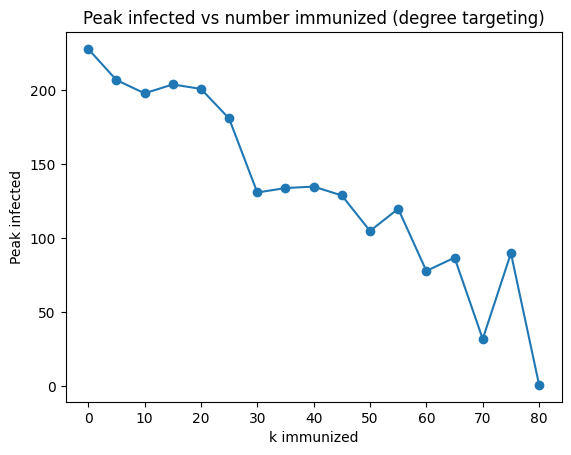

In [24]:
def peak_infected(out):
    return max(out["I"])

k_values = list(range(0, 81, 5))
peaks = []

for k in k_values:
    imm = choose_immunized_by_degree(G, k)
    out = simulate_sir(
        G, beta, gamma, steps, initial_infected,
        immunized=imm,
        rng=np.random.default_rng(42)  # keep fixed for comparability
    )
    peaks.append(peak_infected(out))

plt.plot(k_values, peaks, marker="o")
plt.title("Peak infected vs number immunized (degree targeting)")
plt.xlabel("k immunized")
plt.ylabel("Peak infected")
plt.show()
